
## RESUMEN DEL PIPELINE

✅ **Fases completadas:**

1. **Extracción de 102 Features**: Mel (64) + MFCC (13) + Chroma CQT (12) + Spectral (13)
2. **Normalización Per-Bloque**: Mean/Std computado globalmente y aplicado por bloque
3. **Train/Val Split**: División a nivel de canción (sin leakage)
4. **Serialización TFRecords**: Almacenamiento eficiente de audio + labels
5. **Funciones de Carga**: Parse y dataset pipeline listo para Keras
6. **Modelo CNN+GRU**: Arquitectura para capturar spectrogramas + dinámica temporal

### ¿Qué hace cada componente?

| Fase | Propósito | Entrada | Salida |
|------|-----------|---------|--------|
| Extracción | 102 features por ventana 2s | Audio .mp3 | (102, n_frames) |
| Normalización | Escala features a distribución estándar | X + scaler_info | X_normalized |
| TFRecords | Almacenamiento comprimido | X_norm + labels | .tfrecord binarios |
| Carga | Prepara batches para red neuronal | .tfrecord | tf.data.Dataset |
| CNN+GRU | Predicción valence/arousal | Espectrogramas dinámicos | [valence, arousal] ∈ [-1,1] |

### Siguientes pasos:

```python
# 1. Entrenar el modelo (ejecutar siguiente celda)
history, model_path = train_with_validation(
    model, train_dataset, val_dataset, epochs=20
)

# 2. Evaluar en test (si lo necesitas)
# test_dataset = load_tfrecord_dataset(tfrecord_output, split_name="test", batch_size=32)
# results = model.evaluate(test_dataset)

# 3. Hacer predicciones
# predictions = model.predict(val_dataset)
```

### Archivos generados:

- `intento9/scaler_per_block_102.pkl` → Estadísticas de normalización
- `intento9/tfrecords_102_features/` → Archivos TFRecord (train + val)
- `intento9/best_cnn_gru.keras` → Mejor modelo entrenado


In [1]:
# Verificar la ruta del intérprete de Python que se está usando
import sys
print(sys.executable)

c:\Users\thepe\anaconda3\envs\tf_gpu_clean\python.exe


In [2]:
# Verificar versiones de librerías clave y disponibilidad de GPU
import tensorflow as tf
print("TF:", tf.__version__)
print("NumPy:", __import__("numpy").__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

c:\Users\thepe\anaconda3\envs\tf_gpu_clean\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TF: 2.10.0
NumPy: 1.24.4
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Mostrar dispositivos de computación disponibles (CPU/GPU)
import tensorflow as tf

print("Versión:", tf.__version__)
print("Dispositivos disponibles:", tf.config.list_physical_devices())
print("GPUs:", tf.config.list_physical_devices('GPU'))

Versión: 2.10.0
Dispositivos disponibles: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Información detallada de compilación de TensorFlow y soporte CUDA
import tensorflow as tf
from tensorflow.python.platform import build_info as tf_build_info

print("Versión:", tf.__version__)
print(tf_build_info.build_info)
print("GPU:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA?", tf.test.is_built_with_cuda())
print("Can access GPU?", tf.test.is_gpu_available())

Versión: 2.10.0
OrderedDict([('cpu_compiler', 'C:/Program Files (x86)/Microsoft Visual Studio/2019/Community/VC/Tools/MSVC/14.29.30133/bin/HostX64/x64/cl.exe'), ('cuda_compute_capabilities', ['sm_35', 'sm_50', 'sm_60', 'sm_70', 'sm_75', 'compute_80']), ('cuda_version', '64_112'), ('cudart_dll_name', 'cudart64_112.dll'), ('cudnn_dll_name', 'cudnn64_8.dll'), ('cudnn_version', '64_8'), ('is_cuda_build', True), ('is_rocm_build', False), ('is_tensorrt_build', False), ('msvcp_dll_names', 'msvcp140.dll,msvcp140_1.dll'), ('nvcuda_dll_name', 'nvcuda.dll')])
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA? True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
Can access GPU? True


In [5]:
# Prueba de operación en GPU: multiplicación de matrices grandes
import tensorflow as tf

with tf.device('/GPU:0'):
    a = tf.random.normal([10000, 10000])
    b = tf.random.normal([10000, 10000])
    c = tf.matmul(a, b)

print("✅ Operación completada en GPU")
print(c)

✅ Operación completada en GPU
tf.Tensor(
[[  85.37671     33.127277  -135.73354   ... -133.94972   -159.87752
     3.8853445]
 [ -59.29678   -144.85529    -13.860206  ...   11.413029    44.431236
   154.33665  ]
 [  64.46946   -234.37105    -63.625626  ... -154.94101     19.8473
  -193.48083  ]
 ...
 [ -12.347926   -77.917175   -88.88147   ...   32.45281    -35.40576
    23.897255 ]
 [ -53.39546    -35.302547  -124.59706   ...  -76.35769   -100.11826
   -32.262814 ]
 [  82.08469     -7.648667   -36.035343  ...   -5.2027087  -41.1545
   189.40039  ]], shape=(10000, 10000), dtype=float32)


LEER ARCHIVOS DE DEAM (FORMATEADOS COMO SE MUESTRA PMEMO)

In [6]:
# Cargar datos de anotaciones DEAM: valence (0-1) y arousal (0-1) por segundo
import pandas as pd

# Leer CSV con anotaciones de valence y arousal para cada canción (por segundo)
deam_valence = pd.read_csv("C:/Users/thepe/Downloads/DEAM/DEAM_Annotations/annotations/annotations averaged per song/dynamic (per second annotations)/valence.csv")
deam_arousal = pd.read_csv("C:/Users/thepe/Downloads/DEAM/DEAM_Annotations/annotations/annotations averaged per song/dynamic (per second annotations)/arousal.csv")

In [7]:
deam_valence

,song_id,sample_15000ms,sample_15500ms,sample_16000ms,sample_16500ms,sample_17000ms,sample_17500ms,sample_18000ms,sample_18500ms,sample_19000ms,...,sample_621500ms,sample_622000ms,sample_622500ms,sample_623000ms,sample_623500ms,sample_624000ms,sample_624500ms,sample_625000ms,sample_625500ms,sample_626000ms
0,2,-0.073341,-0.074661,-0.074077,-0.078154,-0.081588,-0.080873,-0.083611,-0.082145,-0.081632,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,-0.189702,-0.187765,-0.183740,-0.188761,-0.193704,-0.190834,-0.189041,-0.197554,-0.202871,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,0.154286,0.148063,0.146956,0.151180,0.135942,0.076832,0.084487,0.088513,0.090944,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,0.149053,0.148260,0.147369,0.146956,0.147857,0.146927,0.145651,0.145795,0.146420,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7,0.342816,0.345193,0.332023,0.328887,0.327603,0.329011,0.327883,0.334822,0.328447,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1797,2054,0.088000,0.088000,0.086000,0.080000,0.070000,0.068000,0.076000,0.078000,0.074000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1798,2055,0.128000,0.098000,0.080000,0.080000,0.088000,0.088000,0.086000,0.078000,0.068000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1799,2056,0.198000,0.182000,0.164000,0.156000,0.148000,0.142000,0.144000,0.146000,0.160000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1800,2057,-0.071667,-0.061667,-0.076667,-0.078333,-0.081667,-0.046667,-0.046667,-0.068333,-0.113333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
deam_arousal

,song_id,sample_15000ms,sample_15500ms,sample_16000ms,sample_16500ms,sample_17000ms,sample_17500ms,sample_18000ms,sample_18500ms,sample_19000ms,...,sample_622000ms,sample_622500ms,sample_623000ms,sample_623500ms,sample_624000ms,sample_624500ms,sample_625000ms,sample_625500ms,sample_626000ms,sample_626500ms
0,2,-0.109386,-0.114942,-1.164126e-01,-0.118613,-1.264569e-01,-0.133199,-0.136855,-0.144713,-0.138985,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,-0.110846,-0.123973,-1.311026e-01,-0.135956,-1.407755e-01,-0.144664,-0.163118,-0.165218,-0.158858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,0.222327,0.179446,1.783881e-01,0.184056,1.760421e-01,0.178720,0.176345,0.175793,0.176154,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,-0.255613,-0.251579,-2.519577e-01,-0.251124,-2.507627e-01,-0.251957,-0.251957,-0.251957,-0.251957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7,0.464234,0.460789,4.609907e-01,0.461046,4.572397e-01,0.465702,0.471809,0.469918,0.473377,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1797,2054,-0.190000,-0.182000,-1.800000e-01,-0.158000,-1.560000e-01,-0.150000,-0.152000,-0.150000,-0.150000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1798,2055,-0.070000,-0.086000,-1.100000e-01,-0.072000,-6.200000e-02,-0.062000,-0.076000,-0.062000,-0.042000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1799,2056,-0.044000,-0.044000,-4.400000e-02,-0.044000,-4.200000e-02,-0.046000,-0.050000,-0.052000,-0.052000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1800,2057,0.413333,0.413333,4.116667e-01,0.410000,4.066667e-01,0.410000,0.401667,0.371667,0.340000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Transformar datos DEAM de formato ancho (una fila por canción, múltiples columnas por tiempo)
# a formato largo (una fila por canción-tiempo)
import pandas as pd

# Pivotar de formato ancho a largo: crea filas (song_id, frame, valor)
deam_valence_long = deam_valence.melt(id_vars=["song_id"],
                                      var_name="frame",
                                      value_name="valence")
deam_arousal_long = deam_arousal.melt(id_vars=["song_id"],
                                      var_name="frame",
                                      value_name="arousal")

# Combinar valence y arousal en un solo DataFrame
deam = pd.merge(deam_valence_long, deam_arousal_long,
                on=["song_id", "frame"])

# Convertir frame de "sample_15000ms" a segundos (tiempo numérico)
deam["time"] = deam["frame"].str.replace("sample_", "").str.replace("ms", "").astype(int) / 1000
deam = deam.drop(columns=["frame"])

In [10]:
# Renombrar columnas para estandarizar (musicId, frameTime) y ordenar por canción y tiempo
deam = deam.rename(columns={"song_id": "musicId", "time": "frameTime"})
deam = deam.sort_values(by=["musicId", "frameTime"]).reset_index(drop=True)

In [11]:
deam

,musicId,valence,arousal,frameTime
0,2,-0.073341,-0.109386,15.0
1,2,-0.074661,-0.114942,15.5
2,2,-0.074077,-0.116413,16.0
3,2,-0.078154,-0.118613,16.5
4,2,-0.081588,-0.126457,17.0
...,...,...,...,...
2203841,2058,NaN,NaN,624.0
2203842,2058,NaN,NaN,624.5
2203843,2058,NaN,NaN,625.0
2203844,2058,NaN,NaN,625.5


In [12]:
# Cargar datos de PMEmo: anotaciones de valence y arousal (dinámicas por segundo)
pmemo = pd.read_csv("C:/Users/thepe/Downloads/PMEmo2019/PMEmo2019/annotations/dynamic_annotations.csv")

In [13]:
pmemo

,musicId,frameTime,Arousal(mean),Valence(mean)
0,1,15.5,0.437663,0.559975
1,1,16.0,0.437775,0.560650
2,1,16.5,0.443125,0.559900
3,1,17.0,0.442887,0.560212
4,1,17.5,0.444563,0.563337
...,...,...,...,...
36429,1000,75.0,0.657438,0.593450
36430,1000,75.5,0.641650,0.591437
36431,1000,76.0,0.641650,0.588437
36432,1000,76.5,0.637537,0.588437


In [14]:
# Renombrar columnas de PMEmo para estandarizar el nombre
pmemo = pmemo.rename(columns={
    "Arousal(mean)": "arousal",
    "Valence(mean)": "valence"
})

NORMALIZACIÓN (-1, 1)

In [15]:
# Normalizar PMEmo de rango [0,1] a [-1,1] (como DEAM está originalmente en [0,1])
# Usar fórmula: normalized = 2 * original - 1
pmemo["arousal"] = 2 * pmemo["arousal"] - 1
pmemo["valence"] = 2 * pmemo["valence"] - 1

In [16]:
pmemo

,musicId,frameTime,arousal,valence
0,1,15.5,-0.124675,0.119950
1,1,16.0,-0.124450,0.121300
2,1,16.5,-0.113750,0.119800
3,1,17.0,-0.114225,0.120425
4,1,17.5,-0.110875,0.126675
...,...,...,...,...
36429,1000,75.0,0.314875,0.186900
36430,1000,75.5,0.283300,0.182875
36431,1000,76.0,0.283300,0.176875
36432,1000,76.5,0.275075,0.176875


AGREGAR COLUMNA PARA IDENTIFICAR DATASET Y CANCIÓN

In [17]:
# Agregar columna "dataset" para identificar fuente: DEAM o PMEmo
# Esto permite saber qué dataset tiene cada anotación
deam["dataset"] = "DEAM"

# Hacer lo mismo para PMEmo
pmemo["dataset"] = "PMEmo"

UNIFICAR

In [18]:
# Combinar DEAM y PMEmo en un único DataFrame para procesamiento unificado
all_data = pd.concat([deam, pmemo], ignore_index=True)

In [19]:
all_data

,musicId,valence,arousal,frameTime,dataset
0,2,-0.073341,-0.109386,15.0,DEAM
1,2,-0.074661,-0.114942,15.5,DEAM
2,2,-0.074077,-0.116413,16.0,DEAM
3,2,-0.078154,-0.118613,16.5,DEAM
4,2,-0.081588,-0.126457,17.0,DEAM
...,...,...,...,...,...
2240275,1000,0.186900,0.314875,75.0,PMEmo
2240276,1000,0.182875,0.283300,75.5,PMEmo
2240277,1000,0.176875,0.283300,76.0,PMEmo
2240278,1000,0.176875,0.275075,76.5,PMEmo


Revisar si existen nulos INTERNOS

In [20]:
# Detectar valores NaN DENTRO del rango válido de cada canción
# Esto identifica anotaciones faltantes mientras la canción estaba siendo anotada
# (no es falta de audio, sino anotación incompleta)
internal_nans = []

for (dataset, musicId), group in all_data.groupby(["dataset", "musicId"]):
    group = group.sort_values("frameTime")

    # Rango válido: desde min hasta max frameTime que tiene anotaciones válidas
    valid = group.dropna(subset=["valence", "arousal"])
    if valid.empty:
        continue  # Canción sin anotaciones útiles

    min_t, max_t = valid["frameTime"].min(), valid["frameTime"].max()

    # Filtrar solo los tiempos que están dentro del rango válido
    mask_range = (group["frameTime"] >= min_t) & (group["frameTime"] <= max_t)
    in_range = group[mask_range]

    # Buscar NaN dentro de este rango
    nan_rows = in_range[in_range["valence"].isnull() | in_range["arousal"].isnull()]

    if not nan_rows.empty:
        internal_nans.append(nan_rows)

if internal_nans:
    internal_nans = pd.concat(internal_nans, ignore_index=True)
else:
    internal_nans = pd.DataFrame()

print(f"Total de nulos internos encontrados: {len(internal_nans)}")
print(internal_nans.head(20))

Total de nulos internos encontrados: 0
Empty DataFrame
Columns: []
Index: []


Revisar si existen nulos EXTERNOS

In [21]:
# Contar valores faltantes por columna
# Si hay muchos NaN en valence/arousal, significa datos incompletos
print(all_data.isnull().sum())

musicId            0
valence      2073848
arousal      2073848
frameTime          0
dataset            0
dtype: int64


In [22]:
# Mostrar muestras donde faltan valores de valence o arousal
nulos = all_data[all_data["valence"].isnull() | all_data["arousal"].isnull()]
print(nulos.head())

    musicId  valence  arousal  frameTime dataset
60        2      NaN      NaN       45.0    DEAM
61        2      NaN      NaN       45.5    DEAM
62        2      NaN      NaN       46.0    DEAM
63        2      NaN      NaN       46.5    DEAM
64        2      NaN      NaN       47.0    DEAM


ELIMINACIÓN DE NULOS (PORQUE LA CANCIÓN YA TERMINÓ)

In [23]:
# Crear versión limpia del dataset: eliminar filas con NaN en valence o arousal
# Estos NaN representan muestras al final de la canción (después del audio disponible)
all_data_clean = all_data.dropna(subset=["valence", "arousal"]).reset_index(drop=True)

In [24]:
# Verificar que no quedan valores NaN en las columnas críticas
print(all_data_clean.isnull().sum())

musicId      0
valence      0
arousal      0
frameTime    0
dataset      0
dtype: int64


In [25]:
all_data_clean.count() # 166429 para todas las columnas

musicId      166429
valence      166429
arousal      166429
frameTime    166429
dataset      166429
dtype: int64

In [26]:
all_data_clean.head()

,musicId,valence,arousal,frameTime,dataset
0,2,-0.073341,-0.109386,15.0,DEAM
1,2,-0.074661,-0.114942,15.5,DEAM
2,2,-0.074077,-0.116413,16.0,DEAM
3,2,-0.078154,-0.118613,16.5,DEAM
4,2,-0.081588,-0.126457,17.0,DEAM


In [27]:
all_data_clean.tail()

,musicId,valence,arousal,frameTime,dataset
166424,1000,0.186900,0.314875,75.0,PMEmo
166425,1000,0.182875,0.283300,75.5,PMEmo
166426,1000,0.176875,0.283300,76.0,PMEmo
166427,1000,0.176875,0.275075,76.5,PMEmo
166428,1000,0.176225,0.155300,77.0,PMEmo


VERIFICACIÓN DE DATOS CRÍTICOS

In [28]:
# Función para verificar que las anotaciones están en el rango [-1, 1]
# y calcular estadísticas básicas (media, desv.est.) por dataset
def check_label_distribution(all_data_clean):
    print("=== Distribución de Labels ===")
    print("Valence - Min: %.3f, Max: %.3f, Mean: %.3f" % 
          (all_data_clean['valence'].min(), all_data_clean['valence'].max(), 
           all_data_clean['valence'].mean()))
    print("Arousal - Min: %.3f, Max: %.3f, Mean: %.3f" % 
          (all_data_clean['arousal'].min(), all_data_clean['arousal'].max(), 
           all_data_clean['arousal'].mean()))
    
    # Mostrar estadísticas separadas por cada dataset
    for dataset in all_data_clean['dataset'].unique():
        subset = all_data_clean[all_data_clean['dataset'] == dataset]
        print(f"\n{dataset}: {len(subset)} samples")
        print(f"Valence: mean={subset['valence'].mean():.3f}, std={subset['valence'].std():.3f}")
        print(f"Arousal: mean={subset['arousal'].mean():.3f}, std={subset['arousal'].std():.3f}")

check_label_distribution(all_data_clean)

=== Distribución de Labels ===
Valence - Min: -0.832, Max: 0.859, Mean: 0.107
Arousal - Min: -0.809, Max: 0.943, Mean: 0.158

DEAM: 129995 samples
Valence: mean=0.077, std=0.251
Arousal: mean=0.127, std=0.283

PMEmo: 36434 samples
Valence: mean=0.214, std=0.320
Arousal: mean=0.265, std=0.354


HALLAR RUTA DE ARCHIVO

In [29]:
# Configurar rutas base para acceder a los archivos de audio
# Cada dataset (DEAM, PMEmo) tiene su propia carpeta con archivos .mp3
import os

AUDIO_BASE = {
    "DEAM": "C:/Users/thepe/Downloads/DEAM/DEAM_audio/MEMD_audio",
    "PMEmo": "C:/Users/thepe/Downloads/PMEmo2019/PMEmo2019/chorus",
}

OUTPUT_PATH = "C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED"
os.makedirs(OUTPUT_PATH, exist_ok=True)

def get_audio_path(row):
    """
    Construir la ruta completa al archivo de audio basándose en dataset y musicId
    """
    base_path = AUDIO_BASE.get(row["dataset"])
    if base_path is None:
        raise ValueError(f"Dataset desconocido: {row['dataset']}")
    return os.path.join(base_path, f"{row['musicId']}.mp3")


### FASE 1: EXTRACCIÓN DE 102 FEATURES MUSICALES


In [30]:
# Importar librerías para procesamiento de audio y análisis numérico
import librosa
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ==================== PARÁMETROS GLOBALES PARA AUDIO ====================
SAMPLE_RATE = 22050          # Frecuencia de muestreo estándar (Hz)
WINDOW_SIZE = 2              # Ventana temporal: 2 segundos por muestra
HOP_LENGTH = 512             # Salto entre frames de análisis (~23ms)
N_MELS = 64                  # Número de bandas de filtro mel

# ==================== DEFINICIÓN GLOBAL DE BLOQUES DE FEATURES ====================
# NUNCA repliques esta lista - debe estar centralizada para evitar inconsistencias
FEATURE_BLOCKS_FIXED = [
    ("Mel", 64),                    # Mel Spectrogram: 64 bins
    ("MFCC", 13),                   # Coeficientes Mel-Frequency Cepstral: 13
    ("Chroma_CQT", 12),             # Pitch class features: 12 notas musicales
    ("Spectral_Centroid", 1),       # Centro de gravedad espectral: 1
    ("Spectral_Bandwidth", 1),      # Ancho de banda espectral: 1
    ("Spectral_Contrast", 7),       # Contraste espectral (7 bandas): 7
    ("Spectral_Rolloff", 1),        # Frecuencia de corte espectral: 1
    ("Spectral_Flatness", 1),       # Planicidad espectral: 1
    ("RMS", 1),                     # Root Mean Square energy: 1
    ("Zero_Crossing", 1),           # Tasa de cruces por cero: 1
]

# Validar que suma total sea 102
TOTAL_FEATURES = sum(count for _, count in FEATURE_BLOCKS_FIXED)
print(f"✅ Total features definidos: {TOTAL_FEATURES}")

✅ Total features definidos: 102


In [31]:
def load_centered_audio_segment(audio_path, center_time_sec, window_sec=2, sr=SAMPLE_RATE):
    """
    Carga un segmento de audio CENTRADO en 'center_time_sec'.
    
    Ejemplo: center_time=10, window_sec=2 → carga de 9 a 11 segundos
    
    Si el segmento está fuera de límites:
    - Rellena con ceros al principio (si center_time < 1 segundo)
    - Rellena con ceros al final (si está cerca del fin de la canción)
    
    Args:
        audio_path: ruta al archivo .mp3
        center_time_sec: tiempo en segundos donde centrar la ventana
        window_sec: tamaño de ventana en segundos (default 2)
        sr: sample rate (default 22050)
    
    Returns:
        (y, sr): audio array y sample rate, o (None, sr) si hay error
    """
    start_sec = center_time_sec - window_sec / 2
    end_sec = center_time_sec + window_sec / 2
    
    # Cargar archivo de audio completo
    try:
        y, sr = librosa.load(audio_path, sr=sr)
    except Exception as e:
        print(f"❌ Error cargando {audio_path}: {e}")
        return None, sr
    
    # Convertir tiempo a índices de samples
    start_sample = max(0, int(start_sec * sr))
    end_sample = min(len(y), int(end_sec * sr))
    
    # Extraer el segmento especificado
    segment = y[start_sample:end_sample]
    
    # Rellenar si es necesario (si está muy cerca del inicio o final)
    target_length = int(window_sec * sr)
    if len(segment) < target_length:
        samples_before = start_sample - int(start_sec * sr)
        segment = np.pad(segment, (samples_before, target_length - len(segment) - samples_before), mode='constant')
    
    return segment[:target_length], sr

def extract_features(y, sr=SAMPLE_RATE, hop_length=HOP_LENGTH):
    """
    Extrae 102 features musicales en orden específico.
    
    El orden es CRÍTICO para que coincida con FEATURE_BLOCKS_FIXED.
    
    Args:
        y: audio waveform (array de samples)
        sr: sample rate (Hz)
        hop_length: salto entre frames
    
    Returns:
        X: ndarray de forma (102, n_frames) o None si hay error
    """
    if y is None or len(y) == 0:
        return None
    
    features_list = []
    
    # 1. Mel Spectrogram (64 features) - representación tiempo-frecuencia
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=hop_length)
    S_db = librosa.power_to_db(S, ref=np.max)  # Convertir a dB
    features_list.append(S_db)  # Forma: (64, n_frames)
    
    # 2. MFCC (13 features) - coeficientes mel-frequency cepstral (estáticos, SIN deltas)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=hop_length)
    features_list.append(mfcc)  # Forma: (13, n_frames)
    
    # 3. Chroma CQT (12 features) - notas musicales (C, C#, D, ..., B)
    chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop_length)
    features_list.append(chroma_cqt)  # Forma: (12, n_frames)
    
    # 4-10. Features espectrales varios
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=hop_length)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=hop_length)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=hop_length)
    
    features_list.append(spectral_centroid)   # Forma: (1, n_frames)
    features_list.append(spectral_bandwidth)  # Forma: (1, n_frames)
    features_list.append(spectral_contrast)   # Forma: (7, n_frames)
    features_list.append(spectral_rolloff)    # Forma: (1, n_frames)
    
    # 11-12. Planicidad espectral y energía RMS
    spectral_flatness = librosa.feature.spectral_flatness(y=y, hop_length=hop_length)
    rms = librosa.feature.rms(y=y, hop_length=hop_length)
    
    features_list.append(spectral_flatness)   # Forma: (1, n_frames)
    features_list.append(rms)                 # Forma: (1, n_frames)
    
    # 13. Tasa de cruces por cero - cambios de signo en la onda (indica ruido/fricativos)
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)
    features_list.append(zcr)                 # Forma: (1, n_frames)
    
    # Concatenar todas en un array de (102, n_frames)
    X = np.vstack(features_list)
    
    return X

print("✅ Funciones de carga y extracción de features definidas")

✅ Funciones de carga y extracción de features definidas


In [32]:
def get_window_labels(row, all_data_clean, window_sec=2):
    """
    Obtiene los labels (valence, arousal) promediados para la ventana de tiempo.
    
    Si múltiples anotaciones caen en la ventana de 2 segundos, promediarlas.
    Si no hay anotaciones disponibles en la ventana, retorna (None, None).
    
    Args:
        row: fila de datos (dataset, musicId, frameTime, ...)
        all_data_clean: DataFrame completo con todas las anotaciones
        window_sec: tamaño de ventana en segundos
    
    Returns:
        (val_mean, aro_mean) o (None, None)
    """
    dataset = row["dataset"]
    musicId = row["musicId"]
    center_time = row["frameTime"]
    
    # Definir rango temporal: center_time ± window_sec/2
    start_time = center_time - window_sec / 2
    end_time = center_time + window_sec / 2
    
    # Filtrar anotaciones de la MISMA canción que caen dentro del rango
    same_song = all_data_clean[
        (all_data_clean["dataset"] == dataset) &
        (all_data_clean["musicId"] == musicId) &
        (all_data_clean["frameTime"] >= start_time) &
        (all_data_clean["frameTime"] <= end_time)
    ]
    
    if same_song.empty:
        return None, None
    
    # Promediar valence y arousal de todas las anotaciones en la ventana
    val_mean = same_song["valence"].mean()
    aro_mean = same_song["arousal"].mean()
    
    return val_mean, aro_mean

print("✅ Función de agregación de labels definida")

✅ Función de agregación de labels definida



### FASE 2: COMPUTAR SCALER GLOBAL (normalización per-bloque)


In [33]:
import joblib

def compute_global_scaler(all_data_clean, sample_limit=5000, random_seed=42):
    """
    Computa estadísticas de normalización (mean, std) PER BLOQUE de features.
    
    Procesa una muestra del dataset para acelerar, luego calcula mean/std
    para cada bloque (Mel, MFCC, Chroma, etc.)
    
    CRÍTICO: Este scaler se aplicará después para normalizar TODOS los features.
    
    Args:
        all_data_clean: DataFrame con [musicId, frameTime, valence, arousal, dataset]
        sample_limit: número máximo de muestras a usar (para acelerar cálculo)
        random_seed: para reproducibilidad
    
    Returns:
        dict con estructura: 
        {
            "block_name": {
                "mean": array de means,
                "std": array de desv.est,
                "count": número de features en ese bloque
            },
            ...
        }
    """
    np.random.seed(random_seed) # Fijar semilla para reproducibilidad
    
    # Muestrear filas aleatoriamente
    sample_indices = np.random.choice(len(all_data_clean), 
                                      size=min(sample_limit, len(all_data_clean)),
                                      replace=False)
    sample_df = all_data_clean.iloc[sample_indices].reset_index(drop=True) # DataFrame muestreado
    
    print(f"📊 Computando scaler con {len(sample_df)} muestras...")
    
    scaler_info = {} # Diccionario para guardar mean/std por bloque
    block_start = 0 # Índice inicial para cada bloque de features
    
    # Iterar sobre cada bloque de features
    for block_name, block_count in FEATURE_BLOCKS_FIXED:
        block_features = []
        
        for idx, row in sample_df.iterrows():
            audio_path = get_audio_path(row)
            
            try:
                # Cargar y extraer features para esta muestra
                y, sr = load_centered_audio_segment(audio_path, row["frameTime"])
                if y is None:
                    continue
                
                X = extract_features(y, sr)
                if X is None:
                    continue
                
                # Extraer solo este bloque específico
                block_data = X[block_start:block_start + block_count, :] # Extraer bloque
                block_features.append(block_data.flatten()) # Agregar features del bloque
                
            except Exception as e:
                print(f"⚠️  Error en {audio_path}: {e}")
                continue
        
        # Calcular estadísticas para este bloque
        if block_features:
            block_array = np.array(block_features)
            scaler_info[block_name] = {
                "mean": block_array.mean(axis=0),
                "std": block_array.std(axis=0),
                "count": block_count,
            }
            print(f"  ✅ {block_name}: mean≈{scaler_info[block_name]['mean'].mean():.4f}, "
                  f"std≈{scaler_info[block_name]['std'].mean():.4f}")
        else:
            print(f"  ⚠️  {block_name}: sin datos válidos")
        
        block_start += block_count
    
    # Guardar scaler para uso posterior
    scaler_path = os.path.join(OUTPUT_PATH, "scaler_per_block_102.pkl")
    joblib.dump(scaler_info, scaler_path)
    print(f"\n✅ Scaler guardado en: {scaler_path}")
    
    return scaler_info

In [ ]:
# Computar scaler (CRITICAL para normalización posterior)
scaler_info = compute_global_scaler(all_data_clean, sample_limit=5000)

In [34]:
# Cargar scaler existente si está disponible, de lo contrario calcularlo
scaler_path = os.path.join(OUTPUT_PATH, "scaler_per_block_102.pkl")

if os.path.exists(scaler_path):
    # Si ya existe el scaler, cargarlo (más rápido)
    scaler_info = joblib.load(scaler_path)
    print(f"✅ Scaler cargado desde: {scaler_path}")
    print(f"   Bloques disponibles: {list(scaler_info.keys())}")
else:
    # Si no existe, calcularlo a partir de muestras
    print(f"⚠️  Scaler no encontrado en {scaler_path}")
    print(f"   Ejecutando compute_global_scaler()...")
    scaler_info = compute_global_scaler(all_data_clean, sample_limit=5000)

✅ Scaler cargado desde: C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\scaler_per_block_102.pkl
   Bloques disponibles: ['Mel', 'MFCC', 'Chroma_CQT', 'Spectral_Centroid', 'Spectral_Bandwidth', 'Spectral_Contrast', 'Spectral_Rolloff', 'Spectral_Flatness', 'RMS', 'Zero_Crossing']


In [35]:
def apply_per_block_normalization(X, scaler_info):
    """
    Normaliza features X aplicando (x - mean) / std PER BLOQUE.
    
    Esto estandariza cada bloque de features (Mel, MFCC, Chroma, etc.)
    de forma independiente, lo que estabiliza el entrenamiento.
    
    Fórmula: X_norm[i] = (X[i] - mean[i]) / std[i]
    
    Args:
        X: ndarray de forma (102, n_frames)
        scaler_info: dict con mean y std por bloque (de compute_global_scaler)
    
    Returns:
        X_normalized: ndarray normalizado, o None si hay error
    """
    if X is None:
        return None
    
    X_norm = X.copy().astype(np.float32) # Copia para no modificar original
    block_start = 0
    
    # Iterar sobre cada bloque
    for block_name, block_count in FEATURE_BLOCKS_FIXED:
        if block_name not in scaler_info:
            print(f"⚠️  Bloque {block_name} no en scaler_info")
            continue
        
        mean = scaler_info[block_name]["mean"]
        std = scaler_info[block_name]["std"]
        
        # Extraer este bloque
        block_data = X_norm[block_start:block_start + block_count, :]
        
        # Evitar división por cero
        std_safe = np.where(std > 0, std, 1.0)
        
        # Normalizar cada feature del bloque
        for feat_idx in range(block_count):
            if feat_idx < len(mean):
                block_data[feat_idx, :] = (block_data[feat_idx, :] - mean[feat_idx]) / std_safe[feat_idx]
        
        block_start += block_count
    
    return X_norm

print("✅ Función de normalización per-bloque definida")

✅ Función de normalización per-bloque definida



### FASE 3: CREAR SPLIT TRAIN/VAL (por canción, evitando leakage)


In [36]:
def create_train_val_split_by_music(all_data_clean, val_frac=0.2, seed=42):
    """
    Divide el dataset a nivel de CANCIÓN (musicId), no por muestra individual.
    
    IMPORTANTE: Esto evita leakage - la MISMA canción no aparece en train y val.
    
    Ejemplo:
    - Total: 100 canciones
    - Val: 20 canciones (20% de 100)
    - Train: 80 canciones (80% de 100)
    
    Args:
        all_data_clean: DataFrame con todas las muestras
        val_frac: fracción de canciones para validación (default 0.2 = 20%)
        seed: para reproducibilidad
    
    Returns:
        (train_df, val_df): DataFrames separados
    """
    np.random.seed(seed)
    
    # Obtener lista única de (dataset, musicId)
    music_list = []
    for dataset in all_data_clean["dataset"].unique():
        subset = all_data_clean[all_data_clean["dataset"] == dataset]
        unique_music = sorted(subset["musicId"].unique())
        music_list.extend([(dataset, mid) for mid in unique_music])
    
    # Mezclar aleatoriamente para distribución uniforme
    music_list = np.array(music_list, dtype=object)
    np.random.shuffle(music_list)
    
    # Dividir: primeras N son validación, resto entrenamiento
    n_val = max(1, int(len(music_list) * val_frac)) # Al menos 1 canción en val
    val_music = set([(d, m) for d, m in music_list[:n_val]]) # Conjunto de canciones de validación
    train_music = set([(d, m) for d, m in music_list[n_val:]]) # Conjunto de canciones de entrenamiento
    
    # Asignar TODAS las muestras de cada canción a train o val
    train_mask = all_data_clean.apply(
        lambda row: (row["dataset"], row["musicId"]) in train_music,
        axis=1
    ) # Máscara booleana para train
    val_mask = all_data_clean.apply(
        lambda row: (row["dataset"], row["musicId"]) in val_music,
        axis=1
    ) # Máscara booleana para val
    
    train_df = all_data_clean[train_mask].reset_index(drop=True)
    val_df = all_data_clean[val_mask].reset_index(drop=True)
    
    print(f"📊 Split Train/Val (por canción - sin leakage):")
    print(f"  Train: {len(train_df)} samples ({len(train_music)} canciones)")
    print(f"  Val:   {len(val_df)} samples ({len(val_music)} canciones)")
    
    return train_df, val_df

train_df, val_df = create_train_val_split_by_music(all_data_clean, val_frac=0.2)

📊 Split Train/Val (por canción - sin leakage):
  Train: 133334 samples (2056 canciones)
  Val:   33095 samples (513 canciones)



### FASE 4: GENERAR TFRecords (con normalización)


In [37]:
import tensorflow as tf

def create_tf_example(X_normalized, valence, arousal, musicId, dataset, frameTime):
    """
    Crea un ejemplo de TensorFlow serializado para almacenar en TFRecord.
    
    TFRecord es un formato binario eficiente para almacenar múltiples ejemplos.
    
    Campos almacenados:
        - X: features normalizados (flattened a 1D)
        - valence, arousal: labels objetivo
        - musicId, dataset, frameTime: metadatos
    
    Args:
        X_normalized: ndarray (102, n_frames) ya normalizado
        valence, arousal: labels (floats en [-1, 1])
        musicId, dataset, frameTime: metadatos
    
    Returns:
        bytes: ejemplo serializado listo para TFRecord
    """
    # X tiene forma (102, n_frames) -> flattenear a vector 1D
    X_flat = X_normalized.flatten().astype(np.float32) # Convertir a float32 para eficiencia
    
    # Crear diccionario de features
    feature_dict = {
        'X': tf.train.Feature(float_list=tf.train.FloatList(value=X_flat)), # Features normalizados
        'valence': tf.train.Feature(float_list=tf.train.FloatList(value=[float(valence)])), # Label valence
        'arousal': tf.train.Feature(float_list=tf.train.FloatList(value=[float(arousal)])), # Label arousal
        'musicId': tf.train.Feature(int64_list=tf.train.Int64List(value=[int(musicId)])), # ID de canción
        'dataset': tf.train.Feature(bytes_list=tf.train.BytesList(value=[dataset.encode('utf-8')])), # Nombre del dataset
        'frameTime': tf.train.Feature(float_list=tf.train.FloatList(value=[float(frameTime)])), # Tiempo del frame
    }
    
    # Crear Example y serializarlo
    example = tf.train.Example(features=tf.train.Features(feature=feature_dict)) # Crear Example
    return example.SerializeToString()

def process_and_save_tfrecords(df, output_dir, scaler_info, split_name="train", batch_size=1000):
    """
    Procesa un DataFrame y guarda muestras en archivos TFRecord.
    
    Para cada fila en df:
    1. Carga el audio (2 segundos centrados en frameTime)
    2. Extrae 102 features
    3. Normaliza features usando scaler_info
    4. Serializa y guarda en TFRecord
    
    Args:
        df: DataFrame con [musicId, frameTime, valence, arousal, dataset]
        output_dir: directorio para guardar archivos .tfrecord
        scaler_info: dict con estadísticas de normalización
        split_name: "train" o "val"
        batch_size: muestras por archivo (para evitar archivos muy grandes)
    
    Returns:
        (total_samples, failed_samples): estadísticas de procesamiento
    """
    os.makedirs(output_dir, exist_ok=True)
    
    batch_count = 0
    current_batch = []
    total_samples = 0
    failed_samples = 0
    
    print(f"\n🔄 Procesando {len(df)} samples ({split_name})...")
    
    for idx, row in df.iterrows():
        if idx % 500 == 0:
            print(f"  Progreso: {idx}/{len(df)}")
        
        try:
            # 1. Cargar segmento de audio centrado
            audio_path = get_audio_path(row)
            y, sr = load_centered_audio_segment(audio_path, row["frameTime"])
            
            if y is None:
                failed_samples += 1
                continue
            
            # 2. Extraer 102 features
            X = extract_features(y, sr)
            if X is None:
                failed_samples += 1
                continue
            
            # 3. Normalizar per-bloque
            X_norm = apply_per_block_normalization(X, scaler_info)
            if X_norm is None:
                failed_samples += 1
                continue
            
            # 4. Crear ejemplo serializado
            example = create_tf_example(
                X_norm,
                row["valence"],
                row["arousal"],
                row["musicId"],
                row["dataset"],
                row["frameTime"]
            )
            
            current_batch.append(example)
            total_samples += 1
            
            # Escribir batch cuando esté lleno
            if len(current_batch) >= batch_size:
                batch_file = os.path.join(output_dir, f"{split_name}_batch_{batch_count:03d}.tfrecord") # Nombre del archivo
                writer = tf.io.TFRecordWriter(batch_file) # Crear writer TFRecord
                for ex in current_batch:
                    writer.write(ex) # Escribir cada ejemplo
                writer.close()
                
                print(f"    ✅ {batch_file} ({len(current_batch)} samples)")
                batch_count += 1
                current_batch = []
        
        except Exception as e:
            print(f"    ⚠️  Error en row {idx}: {e}")
            failed_samples += 1
            continue
    
    # Escribir batch final (si quedan muestras)
    if current_batch:
        batch_file = os.path.join(output_dir, f"{split_name}_batch_{batch_count:03d}.tfrecord")
        writer = tf.io.TFRecordWriter(batch_file)
        for ex in current_batch:
            writer.write(ex)
        writer.close()
        print(f"    ✅ {batch_file} ({len(current_batch)} samples)")
    
    print(f"\n✅ {split_name.upper()} procesado: {total_samples} samples exitosos, {failed_samples} fallidos")
    return total_samples, failed_samples

# Generar TFRecords para train y val
tfrecord_output = os.path.join(OUTPUT_PATH, "tfrecords_102_features")

In [ ]:
train_success, train_fail = process_and_save_tfrecords(
    train_df, tfrecord_output, scaler_info, split_name="train", batch_size=1000
)

val_success, val_fail = process_and_save_tfrecords(
    val_df, tfrecord_output, scaler_info, split_name="val", batch_size=1000
)


🔄 Procesando 133334 samples (train)...
  Progreso: 0/133334
  Progreso: 500/133334
    ✅ C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\tfrecords_102_features\train_batch_000.tfrecord (1000 samples)
  Progreso: 1000/133334
  Progreso: 1500/133334
    ✅ C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\tfrecords_102_features\train_batch_001.tfrecord (1000 samples)
  Progreso: 2000/133334
  Progreso: 2500/133334
    ✅ C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\tfrecords_102_features\train_batch_002.tfrecord (1000 samples)
  Progreso: 3000/133334
  Progreso: 3500/133334
    ✅ C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\tfrecords_102_features\train_batch_003.tfrecord (1000 samples)
  Progreso: 4000/133334
  Progreso: 4500/133334
    ✅ C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\tfrecords_102_features\train_batch_004.tfrecord (1000 samples)
  Progreso: 5000/133334
  Progreso: 5500/133334
    ✅ C:/Users/thepe/


### FASE 5: FUNCIONES DE VALIDACIÓN Y CARGA DE TFRecords


In [38]:
def parse_tfrecord_example(serialized_example):
    """
    Parsea un ejemplo individual de TFRecord.
    
    Convierte el formato binario de vuelta a tensores utilizables.
    
    Retorna:
        (X, y) donde:
        - X tiene forma (102, n_frames) - features del audio
        - y tiene forma (2,) - [valence, arousal]
    """
    feature_description = {
        'X': tf.io.VarLenFeature(tf.float32), # Vector flattenizado de features
        'valence': tf.io.FixedLenFeature([], tf.float32), # Label valence
        'arousal': tf.io.FixedLenFeature([], tf.float32), # Label arousal
        'musicId': tf.io.FixedLenFeature([], tf.int64), # ID de canción
        'dataset': tf.io.FixedLenFeature([], tf.string), # Nombre del dataset
        'frameTime': tf.io.FixedLenFeature([], tf.float32), # Tiempo del frame
    }
    
    # Parsear según la descripción
    parsed = tf.io.parse_single_example(serialized_example, feature_description)
    
    # X está en formato sparse (eficiente) - convertir a denso
    X_flat = tf.sparse.to_dense(parsed['X'])
    X = tf.reshape(X_flat, (102, -1))  # Reshape a (102, n_frames)
    
    # Combinar labels en un vector (2,)
    y = tf.stack([parsed['valence'], parsed['arousal']])
    
    # Retornar solo X e y (ignorar metadatos)
    return X, y

def load_tfrecord_dataset(tfrecord_dir, split_name="train", batch_size=32, shuffle_buffer=1000):
    """
    Carga un dataset desde archivos TFRecord.
    
    Busca todos los archivos "train_batch_*.tfrecord" o "val_batch_*.tfrecord"
    en el directorio y los carga en un tf.data.Dataset.
    
    Args:
        tfrecord_dir: directorio con archivos .tfrecord
        split_name: "train" o "val"
        batch_size: tamaño de batch para entrenamiento
        shuffle_buffer: tamaño del buffer de shuffle (train) o 0 (val)
    
    Returns:
        tf.data.Dataset listo para entrenar, o None si no hay archivos
    """
    # Encontrar todos los archivos .tfrecord para este split
    pattern = os.path.join(tfrecord_dir, f"{split_name}_batch_*.tfrecord")
    tfrecord_files = sorted(tf.io.gfile.glob(pattern))
    
    if not tfrecord_files:
        print(f"❌ No se encontraron archivos: {pattern}")
        return None
    
    print(f"✅ Encontrados {len(tfrecord_files)} archivos para {split_name}")
    
    # Crear dataset desde TFRecords
    dataset = tf.data.TFRecordDataset(tfrecord_files)
    dataset = dataset.map(parse_tfrecord_example, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Shuffle solo en train (para evitar correlación entre batches)
    if split_name == "train":
        dataset = dataset.shuffle(shuffle_buffer)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)  # Precarga siguiente batch mientras entrena
    
    return dataset

def verify_tfrecords(tfrecord_dir, num_samples=5):
    """
    Verifica integridad de TFRecords: lee algunos ejemplos y valida el formato.
    
    Comprueba:
    - Que los archivos se puedan leer
    - Que X tenga forma correcta (102, n_frames)
    - Que y tenga forma correcta (2,) con valores en [-1, 1]
    - Que los features estén normalizados (mean≈0, std≈1)
    
    Args:
        tfrecord_dir: directorio con archivos .tfrecord
        num_samples: número de ejemplos a verificar
    
    Returns:
        True si todo OK, False si hay error
    """
    print(f"\n🔍 Verificando TFRecords en {tfrecord_dir}...")
    
    pattern = os.path.join(tfrecord_dir, "*.tfrecord")
    tfrecord_files = sorted(tf.io.gfile.glob(pattern))
    
    if not tfrecord_files:
        print(f"❌ No se encontraron archivos .tfrecord")
        return False
    
    print(f"📁 {len(tfrecord_files)} archivos encontrados")
    
    count = 0
    for tfrecord_file in tfrecord_files:
        for raw_record in tf.data.TFRecordDataset([tfrecord_file]).take(num_samples):
            try:
                # Parsear el ejemplo
                X, y = parse_tfrecord_example(raw_record)
                
                print(f"  Sample: X.shape={X.shape}, y={y.numpy()}")
                
                # Verificar normalización aproximada
                X_mean = tf.reduce_mean(X).numpy()
                X_std = tf.math.reduce_std(X).numpy()
                print(f"    → X: mean≈{X_mean:.4f}, std≈{X_std:.4f}")
                
                count += 1
            except Exception as e:
                print(f"  ❌ Error: {e}")
                return False
    
    print(f"\n✅ Verificación exitosa: {count} samples leídos correctamente")
    return True

print("✅ Funciones de validación y carga de TFRecords definidas")

✅ Funciones de validación y carga de TFRecords definidas



### FASE 6: VALIDACIÓN DE TFRecords Y ESTADÍSTICAS


In [39]:
# Verificar integridad de TFRecords generados
# Lee 3 ejemplos de cada tipo de archivo para validar formato
verify_tfrecords(tfrecord_output, num_samples=3)


🔍 Verificando TFRecords en C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\tfrecords_102_features...
📁 168 archivos encontrados
  Sample: X.shape=(102, 87), y=[-0.0733407 -0.109386 ]
    → X: mean≈-0.7339, std≈1.3770
  Sample: X.shape=(102, 87), y=[-0.0746607 -0.1149416]
    → X: mean≈-0.5705, std≈1.2855
  Sample: X.shape=(102, 87), y=[-0.0740767 -0.1164126]
    → X: mean≈-0.5545, std≈1.2717
  Sample: X.shape=(102, 87), y=[-0.1711795  0.512703 ]
    → X: mean≈-0.5769, std≈1.2656
  Sample: X.shape=(102, 87), y=[-0.1584696  0.502759 ]
    → X: mean≈-0.5700, std≈1.2613
  Sample: X.shape=(102, 87), y=[-0.1630074  0.498675 ]
    → X: mean≈-0.4366, std≈1.2266
  Sample: X.shape=(102, 87), y=[-0.1950931 -0.2286169]
    → X: mean≈-0.8300, std≈1.5987
  Sample: X.shape=(102, 87), y=[-0.1956898 -0.22955  ]
    → X: mean≈-0.7319, std≈1.5440
  Sample: X.shape=(102, 87), y=[-0.1994899 -0.2324285]
    → X: mean≈-0.7596, std≈1.5634
  Sample: X.shape=(102, 87), y=[0.1827443 0.3543832]
   

True


### FASE 7: EJEMPLO DE CARGA Y ENTRENAMIENTO CON CNN+GRU

Esta sección muestra cómo cargar el dataset y construir tu arquitectura CNN+GRU.


In [40]:
# Cargar datasets desde TFRecords CON OPTIMIZACIÓN
# Transposición: (102, n_frames) → (n_frames, 102) para mejor cache locality en redes RNN
print("=" * 60)
print("CARGANDO DATASETS OPTIMIZADOS PARA ENTRENAMIENTO")
print("=" * 60)

def parse_tfrecord_optimized(serialized_example):
    """
    Parse optimizado que retorna X transpuesto.
    
    Forma original: (102, n_frames) = 102 features, ~86 frames
    Forma optimizada: (n_frames, 102) = ~86 frames, 102 features
    
    Esta forma es mejor para RNN/LSTM porque el tiempo es la primera dimensión.
    """
    feature_description = {
        'X': tf.io.VarLenFeature(tf.float32),
        'valence': tf.io.FixedLenFeature([], tf.float32),
        'arousal': tf.io.FixedLenFeature([], tf.float32),
        'musicId': tf.io.FixedLenFeature([], tf.int64),
        'dataset': tf.io.FixedLenFeature([], tf.string),
        'frameTime': tf.io.FixedLenFeature([], tf.float32),
    }
    
    parsed = tf.io.parse_single_example(serialized_example, feature_description)
    
    # Convertir X de sparse a denso
    X_flat = tf.sparse.to_dense(parsed['X']) # Vector flattenizado
    X = tf.reshape(X_flat, (102, -1)) # Reshape a (102, n_frames)
    
    # TRANSPONER: (102, n_frames) → (n_frames, 102) para RNN
    X = tf.transpose(X)
    
    # Combinar labels
    y = tf.stack([parsed['valence'], parsed['arousal']])
    
    return X, y

def load_tfrecord_dataset_optimized(tfrecord_dir, split_name="train", batch_size=64, shuffle_buffer=5000):
    """
    Carga dataset con batch_size más grande (64 en lugar de 32).
    
    Un batch_size más grande es más eficiente en GPU.
    """
    pattern = os.path.join(tfrecord_dir, f"{split_name}_batch_*.tfrecord") # Buscar archivos
    tfrecord_files = sorted(tf.io.gfile.glob(pattern)) # Listar archivos encontrados
    
    if not tfrecord_files:
        print(f"❌ No se encontraron archivos: {pattern}")
        return None
    
    print(f"✅ Encontrados {len(tfrecord_files)} archivos para {split_name}")
    
    dataset = tf.data.TFRecordDataset(tfrecord_files) # Crear dataset
    dataset = dataset.map(parse_tfrecord_optimized, num_parallel_calls=tf.data.AUTOTUNE) # Mapear con parse optimizado
    
    if split_name == "train":
        dataset = dataset.shuffle(shuffle_buffer) # Shuffle solo en train
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Cargar datasets con batch_size=64 (mejor para GPU)
train_dataset_opt = load_tfrecord_dataset_optimized(tfrecord_output, split_name="train", batch_size=64)
val_dataset_opt = load_tfrecord_dataset_optimized(tfrecord_output, split_name="val", batch_size=64)

# Validar que el formato sea correcto para la red neuronal
print("\n📊 Validando formato del dataset optimizado...")
for X_batch, y_batch in train_dataset_opt.take(1):
    print(f"  ✅ X_batch.shape: {X_batch.shape} (esperado: (64, n_frames, 102))")
    print(f"  ✅ y_batch.shape: {y_batch.shape} (esperado: (64, 2))")
    print(f"  ✅ y_batch sample: {y_batch[0].numpy()} (valence, arousal)")

print("\n✅ Datasets optimizados cargados correctamente")

CARGANDO DATASETS OPTIMIZADOS PARA ENTRENAMIENTO
✅ Encontrados 134 archivos para train
✅ Encontrados 34 archivos para val

📊 Validando formato del dataset optimizado...
  ✅ X_batch.shape: (64, 87, 102) (esperado: (64, n_frames, 102))
  ✅ y_batch.shape: (64, 2) (esperado: (64, 2))
  ✅ y_batch sample: [ 0.0370292 -0.0664814] (valence, arousal)

✅ Datasets optimizados cargados correctamente


In [41]:
import tensorflow as tf

# ==================== DEFINICIÓN DE MÉTRICA Y FUNCIÓN DE PÉRDIDA ====================

def ccc_score_tf(y_true, y_pred, eps=1e-8):
    """
    Calcula el Concordance Correlation Coefficient (CCC).
    
    CCC mide acuerdo entre predicción y realidad (mejor que MSE para regresión ordinal).
    Rango: [-1, 1] donde 1 = acuerdo perfecto, 0 = sin acuerdo, -1 = desacuerdo perfecto.
    
    Fórmula: CCC = 2 * cov(y_true, y_pred) / (var(y_true) + var(y_pred) + (mean_true - mean_pred)^2)
    """
    # Asegurar que ambos sean float32 (para evitar problemas con mixed precision)
    y_true = tf.cast(y_true, tf.float32) # Convertir a float32
    y_pred = tf.cast(y_pred, tf.float32) # Convertir a float32

    mean_true = tf.reduce_mean(y_true, axis=0) # Media de y_true
    mean_pred = tf.reduce_mean(y_pred, axis=0) # Media de y_pred
    var_true = tf.reduce_mean(tf.square(y_true - mean_true), axis=0) # Varianza de y_true
    var_pred = tf.reduce_mean(tf.square(y_pred - mean_pred), axis=0) # Varianza de y_pred
    cov = tf.reduce_mean((y_true - mean_true) * (y_pred - mean_pred), axis=0) # Covarianza

    ccc = (2.0 * cov) / (var_true + var_pred + tf.square(mean_true - mean_pred) + eps)
    return ccc

@tf.function
def ccc_metric(y_true, y_pred):
    """
    Métrica CCC promediada: si hay múltiples dimensiones (valence y arousal),
    retorna el promedio de CCC para ambas.
    """
    c = ccc_score_tf(y_true, y_pred)
    return tf.reduce_mean(c)

@tf.function
def ccc_loss(y_true, y_pred):
    """
    Loss basado en CCC: 1 - CCC
    Esto convierte maximización de CCC a minimización de loss.
    """
    c = ccc_score_tf(y_true, y_pred)
    return 1.0 - tf.reduce_mean(c)

def combined_loss(alpha=0.5):
    """
    Loss combinado: alpha * MSE + (1-alpha) * CCC_loss
    
    - MSE proporciona estabilidad (penaliza errores grandes)
    - CCC refina la correlación (lo importante para emoción)
    - alpha=0.5: balance entre ambos
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # MSE: error cuadrático medio (penaliza desviaciones)
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        
        # CCC: correlación de concordancia (para cada dimensión: valence y arousal)
        ccc_val = 1.0 - ccc_valence(y_true, y_pred)
        ccc_aro = 1.0 - ccc_arousal(y_true, y_pred)
        avg_ccc_loss = (ccc_val + ccc_aro) / 2.0
        
        # Combinar: 50% MSE + 50% CCC
        return alpha * mse + (1.0 - alpha) * avg_ccc_loss
    return loss

@tf.function
def ccc_valence(y_true, y_pred):
    """CCC para dimensión 0 (valence solamente)"""
    return ccc_score_tf(y_true[:, 0], y_pred[:, 0])

@tf.function
def ccc_arousal(y_true, y_pred):
    """CCC para dimensión 1 (arousal solamente)"""
    return ccc_score_tf(y_true[:, 1], y_pred[:, 1])

---

# PARTE 2: MODELO LIMPIO DESDE CERO

## Arquitectura: CNN1D → BiGRU → Atención → Dense

**Objetivo**: Dado un audio cualquiera, predecir `[valence, arousal]` ∈ [-1, 1]

**Pipeline**:
1. Audio (MP3) → Cargar 2s centrados
2. Extraer 102 features
3. Normalizar (aplicar scaler precomputado)
4. Red neuronal predice emoción
5. Devolver [valence, arousal]



In [42]:
# ============================================================================
# CAPA DE ATENCIÓN (Reutilizable en cualquier red)
# ============================================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

class AttentionBlock(layers.Layer):
    """
    Capa de atención simple que pondera los frames según su importancia.
    
    Problema: En una canción de 2 segundos, hay ~86 frames.
    ¿Son todos igual de importantes para la emoción?
    
    Solución: Usar atención para dar más peso a frames importantes.
    
    Input: (batch, timesteps, features) = (64, 86, 128)
    Output: (batch, features) = (64, 128) contexto ponderado
    
    Mecanismo:
    1. Calcular score de importancia para cada frame
    2. Aplicar softmax para obtener pesos (suma = 1)
    3. Ponderar frames y sumar (weighted average)
    """
    def __init__(self, **kwargs):
        super(AttentionBlock, self).__init__(**kwargs) # Inicializar capa base
        self.score_dense = layers.Dense(1, activation='tanh') # Capa densa para scores
        self.softmax = layers.Softmax(axis=1) # Softmax sobre timesteps

    def call(self, inputs):
        # inputs: (batch, t, features)
        scores = self.score_dense(inputs)      # (batch, t, 1)
        weights = self.softmax(scores)         # (batch, t, 1) suma a 1 por timestep
        context = tf.reduce_sum(inputs * weights, axis=1)  # (batch, features)
        return context

print("✅ AttentionBlock definida")


✅ AttentionBlock definida


In [43]:
# ============================================================================
# ARQUITECTURA PRINCIPAL: CNN1D → BiGRU → Atención → Dense (VERSIÓN REGULARIZADA)
# ============================================================================

def build_mer_model(
    n_frames=86,
    n_features=102,
    l2_reg=1e-4,
    dropout_spatial=0.4,
    dropout_dense=0.5,
    lr=1e-4
): # Construye el modelo MER regularizado
    """
    Versión regularizada del modelo MER para reducir sobreajuste.
    Cambios clave:
      - Menor número de filtros/unidades para reducir capacidad
      - Dropout espacial más alto
      - recurrent_dropout en GRU para regularizar memoria recurrente
      - LayerNormalization después de la atención
      - GaussianNoise en la entrada para robustez
    """
    inp = layers.Input(shape=(n_frames, n_features), name='input_audio_features') # Input

    # Ruido de entrada (pequeño) para robustez (se activa solo en training)
    x = layers.GaussianNoise(0.01)(inp) # Añadir ruido gaussiano

    # BLOQUE CONV 1D (más pequeño)
    x = layers.Conv1D(16, kernel_size=3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg), name='conv1d_16')(x) # Menos filtros
    x = layers.BatchNormalization()(x) # Normalización por batch
    x = layers.SpatialDropout1D(dropout_spatial)(x) # Dropout espacial

    x = layers.Conv1D(32, kernel_size=3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg), name='conv1d_32')(x) # Menos filtros
    x = layers.BatchNormalization()(x) # Normalización por batch
    x = layers.SpatialDropout1D(dropout_spatial)(x) # Dropout espacial

    x = layers.Conv1D(48, kernel_size=3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg), name='conv1d_48')(x) # Menos filtros
    x = layers.BatchNormalization()(x) # Normalización por batch
    x = layers.SpatialDropout1D(dropout_spatial)(x) # Dropout espacial

    x = layers.MaxPooling1D(pool_size=2, name='maxpool')(x) # Reducción de dimensionalidad

    # BLOQUE BiGRU (más pequeño y con recurrent_dropout)
    # ... (Parte de CNN igual) ...

    # BIDIRECTIONAL GRU: Simplificamos a UNA sola capa más robusta
    x = layers.Bidirectional(
        layers.GRU(32, return_sequences=True, activation='tanh', # Subimos un poco unidades, quitamos una capa
                   kernel_regularizer=regularizers.l2(l2_reg),
                   recurrent_regularizer=regularizers.l2(l2_reg),
                   dropout=0.3, # Dropout interno del GRU
                   recurrent_dropout=0.0) # 0.0 para usar cuDNN (más rápido)
    )(x)
    x = layers.SpatialDropout1D(0.4)(x) # Dropout espacial después del BiGRU

    # ATENCIÓN
    context = AttentionBlock(name='attention')(x) # Capa de atención
    context = layers.LayerNormalization()(context) # Normalización de capa después de atención

    # HEAD DENSO SIMPLIFICADO
    # Quitamos la estructura profunda de Dense->Dropout->Dense->Dropout
    # Vamos directo a la predicción o con una sola capa intermedia muy regularizada
    
    x = layers.Dropout(0.5)(context) # Dropout fuerte antes de la decisión final
    
    # Salida directa (o con una capa de 16 unidades si prefieres)
    output = layers.Dense(2, activation='tanh', dtype='float32', name='output_valence_arousal')(x) # Salida final

    model = models.Model(inputs=inp, outputs=output, name='MER_CNN_BiGRU_Attention_reg') # Modelo completo

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr) # Optimizador Adam
    model.compile(optimizer=optimizer,
                  loss=combined_loss(alpha=0.25),  # más peso a CCC
                  metrics=[ccc_metric, 'mae']) # Métricas: CCC y MAE
    return model

# Reconstruir modelo con la configuración regularizada
print("\n" + "="*60)
print("CONSTRUYENDO MODELO MER (VERSIÓN REGULARIZADA)")
print("="*60)
model = build_mer_model(n_frames=86, n_features=102, l2_reg=1e-4, dropout_spatial=0.4, dropout_dense=0.5, lr=1e-4) # Construir modelo
model.summary()

print("\n✅ Modelo regularizado compilado y listo para entrenar")



CONSTRUYENDO MODELO MER (VERSIÓN REGULARIZADA)
Model: "MER_CNN_BiGRU_Attention_reg"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_audio_features (Input  [(None, 86, 102)]        0         
 Layer)                                                          
                                                                 
 gaussian_noise (GaussianNoi  (None, 86, 102)          0         
 se)                                                             
                                                                 
 conv1d_16 (Conv1D)          (None, 86, 16)            4912      
                                                                 
 batch_normalization (BatchN  (None, 86, 16)           64        
 ormalization)                                                   
                                                                 
 spatial_dropout1d (SpatialD  (None, 86, 16)           0 

In [44]:
# ============================================================================
# ENTRENAMIENTO: Configurar y lanzar
# ============================================================================

print("\n" + "="*70)
print("PREPARAR ENTRENAMIENT0")
print("="*70)

# 1. Cargar/verificar scaler
scaler_path = os.path.join(OUTPUT_PATH, "scaler_per_block_102.pkl")
if os.path.exists(scaler_path):
    scaler_info = joblib.load(scaler_path)
    print(f"✅ Scaler cargado: {len(scaler_info)} bloques")
else:
    print(f"❌ Scaler no encontrado en {scaler_path}")
    print("   Debes ejecutar compute_global_scaler() primero")

def mixup(ds_one, ds_two, alpha=0.2):
    # Desempaquetar
    images_one, labels_one = ds_one
    images_two, labels_two = ds_two

    # Generar lambda de distribución beta
    batch_size = tf.shape(images_one)[0]
    l = tf.random.gamma([batch_size, 1], alpha, 1.0) # Para broadcast correcto
    l = tf.random.gamma([batch_size, 1, 1], alpha, 1.0) # Para broadcast correcto en imagen

    # Mezclar imágenes
    images = l * images_one + (1 - l) * images_two

    # Mezclar etiquetas (Valence, Arousal)
    # Ajustar lambda para dimensiones de etiqueta
    l_labels = tf.reshape(l, [batch_size, 1]) 
    labels = l_labels * labels_one + (1 - l_labels) * labels_two

    return images, labels

# EN TU PIPELINE DE CARGA DE DATOS:
# Asegúrate de que train_dataset tenga drop_remainder=True para que funcione bien
train_dataset = load_tfrecord_dataset_optimized(tfrecord_output, split_name="train", batch_size=32)
val_dataset = load_tfrecord_dataset_optimized(tfrecord_output, split_name="train", batch_size=32).shuffle(1024)

# TODO: Aplicar Mixup solo al dataset de entrenamiento
# Zip del dataset consigo mismo (mezclado)
train_ds_mixup = tf.data.Dataset.zip((train_dataset, train_dataset)) # Mezclar con otro batch del mismo dataset
train_ds_mixup = train_ds_mixup.map(lambda x, y: mixup(x, y, alpha=0.2), num_parallel_calls=tf.data.AUTOTUNE) # Aplicar Mixup
train_ds_mixup = train_ds_mixup.prefetch(tf.data.AUTOTUNE) # Precarga

# IMPORTANTE: Usa 'train_ds_mixup' para model.fit, NO el train_dataset normal.
# NO apliques Mixup al validation set.

# --- Augmentación on-the-fly (solo en train): añadir ruido gaussiano pequeño a features ---
# Esto aumenta la robustez sin regenerar TFRecords
def _augment_features(X, y, noise_std=0.02):
    noise = tf.random.normal(tf.shape(X), mean=0.0, stddev=noise_std, dtype=X.dtype)
    return X + noise, y

# Aplicar augmentación solo al dataset de entrenamiento
train_dataset = train_dataset.map(lambda X, y: _augment_features(X, y, noise_std=0.02), num_parallel_calls=tf.data.AUTOTUNE) # Añadir ruido
# Mantener shuffle/prefetch para rendimiento
train_dataset = train_dataset.shuffle(2000) # Shuffle extra
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE) # Precarga

# Validar
for X_batch, y_batch in train_dataset.take(1):
    print(f"  ✅ Train batch: X={X_batch.shape}, y={y_batch.shape}")
for X_batch, y_batch in val_dataset.take(1):
    print(f"  ✅ Val batch: X={X_batch.shape}, y={y_batch.shape}")

# 3. Definir callbacks
callbacks_training = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_ccc_metric',
        mode='max',
        patience=10,
        restore_best_weights=True,
        verbose=1,
        min_delta=1e-4
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_PATH, 'best_mer_model.keras'),
        monitor='val_ccc_metric',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_ccc_metric',
        mode='max',
        factor=0.2,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
] # Callbacks para entrenamiento

print("\n✅ Configuración lista. Ejecuta la siguiente celda para entrenar.")



PREPARAR ENTRENAMIENT0
✅ Scaler cargado: 10 bloques
✅ Encontrados 134 archivos para train
✅ Encontrados 134 archivos para train
  ✅ Train batch: X=(32, 87, 102), y=(32, 2)
  ✅ Val batch: X=(32, 87, 102), y=(32, 2)

✅ Configuración lista. Ejecuta la siguiente celda para entrenar.


ENTRENAMIENTO SIN APLICAR LO DEL #TODO

In [147]:
# ============================================================================
# ENTRENAR MODELO
# ============================================================================

print("\n" + "="*70)
print("INICIANDO ENTRENAMIENTO")
print("="*70 + "\n")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks_training,
    verbose=1
)

print("\n✅ Entrenamiento completado")

# Guardar modelo
model_final_path = os.path.join(OUTPUT_PATH, 'mer_model_final.keras')
model.save(model_final_path)
print(f"💾 Modelo guardado: {model_final_path}")



INICIANDO ENTRENAMIENTO

Epoch 1/50
   4167/Unknown - 221s 35ms/step - loss: 0.7789 - ccc_metric: 0.1957 - mae: 0.6985
Epoch 1: val_ccc_metric improved from -inf to 0.22826, saving model to C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\best_mer_model.keras

Epoch 1: val_ccc_metric improved from -inf to 0.22826, saving model to C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\best_mer_model.keras
4167/4167 [==============================] - 371s 71ms/step - loss: 0.7789 - ccc_metric: 0.1957 - mae: 0.6985 - val_loss: 0.7726 - val_ccc_metric: 0.2283 - val_mae: 0.7693 - lr: 1.0000e-04
Epoch 2/50
4167/4167 [==============================] - 371s 71ms/step - loss: 0.7789 - ccc_metric: 0.1957 - mae: 0.6985 - val_loss: 0.7726 - val_ccc_metric: 0.2283 - val_mae: 0.7693 - lr: 1.0000e-04
Epoch 2/50
4166/4167 [============================>.] - ETA: 0s - loss: 0.6347 - ccc_metric: 0.2930 - mae: 0.4759
Epoch 2: val_ccc_metric improved from 0.22826 to 0.39748, saving mod

ENTRENAMIENTO DESPUÉS DE APLICAR LO DEL #TODO (train mezclado consigo mismo, sin mezclar con val)

In [45]:
# ============================================================================
# ENTRENAR MODELO
# ============================================================================

print("\n" + "="*70)
print("INICIANDO ENTRENAMIENTO")
print("="*70 + "\n")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks_training,
    verbose=1
)

print("\n✅ Entrenamiento completado")

# Guardar modelo
model_final_path = os.path.join(OUTPUT_PATH, 'mer_model_final.keras')
model.save(model_final_path)
print(f"💾 Modelo guardado: {model_final_path}")


INICIANDO ENTRENAMIENTO

Epoch 1/50
   4165/Unknown - 134s 26ms/step - loss: 0.7731 - ccc_metric: 0.1966 - mae: 0.6814
Epoch 1: val_ccc_metric improved from -inf to 0.24199, saving model to C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\best_mer_model.keras
4167/4167 [==============================] - 186s 39ms/step - loss: 0.7731 - ccc_metric: 0.1966 - mae: 0.6813 - val_loss: 0.7507 - val_ccc_metric: 0.2420 - val_mae: 0.7369 - lr: 1.0000e-04
Epoch 2/50
4167/4167 [==============================] - ETA: 0s - loss: 0.5958 - ccc_metric: 0.3296 - mae: 0.4273
Epoch 2: val_ccc_metric improved from 0.24199 to 0.41016, saving model to C:/Users/thepe/Downloads/preprocessed_improved_features_FIXED\best_mer_model.keras
4167/4167 [==============================] - 165s 37ms/step - loss: 0.5958 - ccc_metric: 0.3296 - mae: 0.4273 - val_loss: 0.5133 - val_ccc_metric: 0.4102 - val_mae: 0.3604 - lr: 1.0000e-04
Epoch 3/50
4166/4167 [============================>.] - ETA: 0s - loss: 0.459

ENTRENAMIENTO ANTES DE APLICAR #TODO

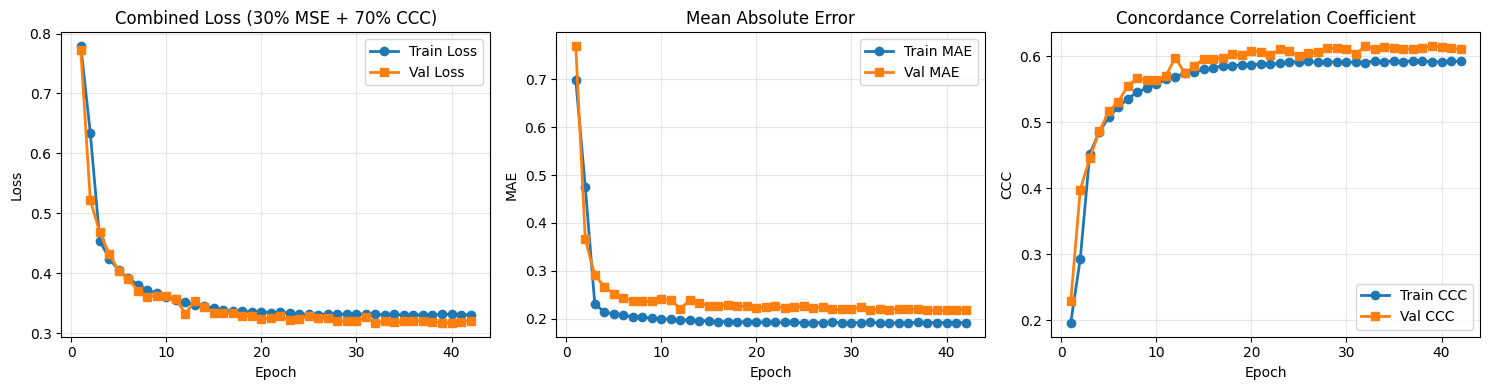


RESUMEN DE ENTRENAMIENTO
Épocas entrenadas: 42
Mejor val_loss: 0.317056
Mejor val_mae: 0.216943
Mejor val_ccc_metric: 0.615045


In [148]:
# ============================================================================
# VISUALIZAR RESULTADOS DEL ENTRENAMIENTO
# ============================================================================

import matplotlib.pyplot as plt

h = history.history
epochs_range = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs_range, h['loss'], 'o-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, h['val_loss'], 's-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Combined Loss (30% MSE + 70% CCC)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(epochs_range, h['mae'], 'o-', label='Train MAE', linewidth=2)
axes[1].plot(epochs_range, h['val_mae'], 's-', label='Val MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# CCC Metric
if 'ccc_metric' in h:
    axes[2].plot(epochs_range, h['ccc_metric'], 'o-', label='Train CCC', linewidth=2)
    axes[2].plot(epochs_range, h['val_ccc_metric'], 's-', label='Val CCC', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('CCC')
    axes[2].set_title('Concordance Correlation Coefficient')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'CCC no disponible', ha='center', va='center')
    axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'training_curves.png'), dpi=100, bbox_inches='tight')
plt.show()

# Resumen
print("\n" + "="*70)
print("RESUMEN DE ENTRENAMIENTO")
print("="*70)
print(f"Épocas entrenadas: {len(h['loss'])}")
print(f"Mejor val_loss: {min(h['val_loss']):.6f}")
print(f"Mejor val_mae: {min(h['val_mae']):.6f}")
if 'val_ccc_metric' in h:
    print(f"Mejor val_ccc_metric: {max(h['val_ccc_metric']):.6f}")
print("="*70)


ENTRENAMIENTO DESPUÉS DE APLICAR #TODO

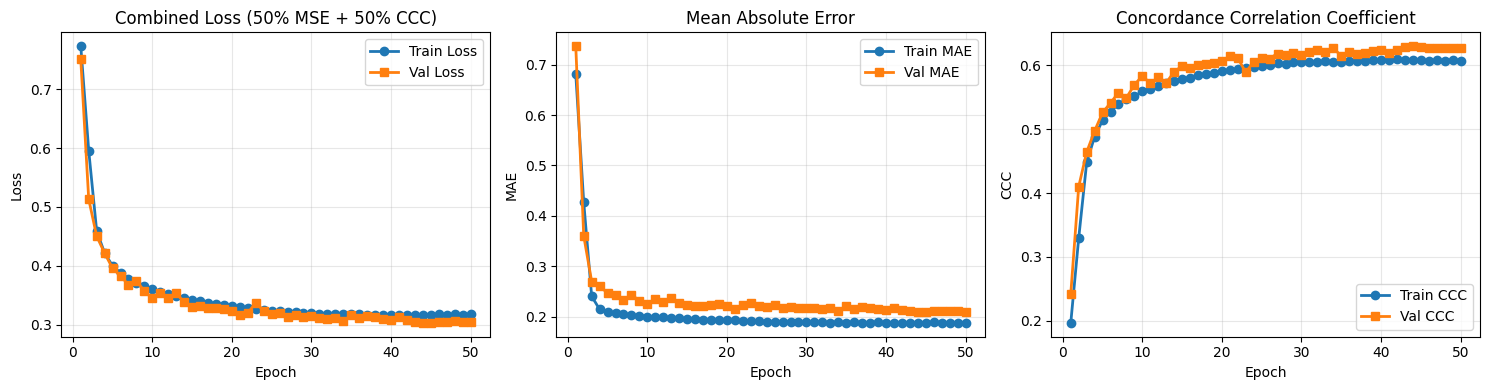


RESUMEN DE ENTRENAMIENTO
Épocas entrenadas: 50
Mejor val_loss: 0.303161
Mejor val_mae: 0.209538
Mejor val_ccc_metric: 0.630127


In [47]:
# ============================================================================
# VISUALIZAR RESULTADOS DEL ENTRENAMIENTO
# ============================================================================

import matplotlib.pyplot as plt

h = history.history
epochs_range = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs_range, h['loss'], 'o-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, h['val_loss'], 's-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Combined Loss (50% MSE + 50% CCC)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(epochs_range, h['mae'], 'o-', label='Train MAE', linewidth=2)
axes[1].plot(epochs_range, h['val_mae'], 's-', label='Val MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# CCC Metric
if 'ccc_metric' in h:
    axes[2].plot(epochs_range, h['ccc_metric'], 'o-', label='Train CCC', linewidth=2)
    axes[2].plot(epochs_range, h['val_ccc_metric'], 's-', label='Val CCC', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('CCC')
    axes[2].set_title('Concordance Correlation Coefficient')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'CCC no disponible', ha='center', va='center')
    axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'training_curves.png'), dpi=100, bbox_inches='tight')
plt.show()

# Resumen
print("\n" + "="*70)
print("RESUMEN DE ENTRENAMIENTO")
print("="*70)
print(f"Épocas entrenadas: {len(h['loss'])}")
print(f"Mejor val_loss: {min(h['val_loss']):.6f}")
print(f"Mejor val_mae: {min(h['val_mae']):.6f}")
if 'val_ccc_metric' in h:
    print(f"Mejor val_ccc_metric: {max(h['val_ccc_metric']):.6f}")
print("="*70)